# Quantium Virtual Internship - Retail Strategy and Analytics - Task 1

## Load required libraries and datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
customerData=pd.read_csv("QVI_purchase_behaviour.csv")

In [3]:
transactionData = pd.read_excel('QVI_transaction_data.xlsx', engine='openpyxl')

In [4]:
transactionData.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
customerData.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


# Exploratory data analysis

### Examining transaction data

In [6]:
transactionData.dtypes

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME             str
PROD_QTY            int64
TOT_SALES         float64
dtype: object

In [7]:
#We can see that the date column is in an integer format. Let's change this to a date format.
transactionData['DATE'] = pd.to_datetime(transactionData['DATE'], origin='1899-12-30', unit='D')

In [8]:
unique_prod=transactionData['PROD_NAME'].unique()

In [9]:
print(unique_prod)

<StringArray>
[  'Natural Chip        Compny SeaSalt175g',
                 'CCs Nacho Cheese    175g',
   'Smiths Crinkle Cut  Chips Chicken 170g',
   'Smiths Chip Thinly  S/Cream&Onion 175g',
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
 'Old El Paso Salsa   Dip Tomato Mild 300g',
 'Smiths Crinkle Chips Salt & Vinegar 330g',
    'Grain Waves         Sweet Chilli 210g',
  'Doritos Corn Chip Mexican Jalapeno 150g',
    'Grain Waves Sour    Cream&Chives 210G',
 ...
         'Doritos Cheese      Supreme 330g',
      'Smiths Crinkle Cut  Snag&Sauce 150g',
   'WW Sour Cream &OnionStacked Chips 160g',
                 'RRD Lime & Pepper   165g',
   'Natural ChipCo Sea  Salt & Vinegr 175g',
    'Red Rock Deli Chikn&Garlic Aioli 150g',
      'RRD SR Slow Rst     Pork Belly 150g',
                 'RRD Pc Sea Salt     165g',
       'Smith Crinkle Cut   Bolognese 150g',
                 'Doritos Salsa Mild  300g']
Length: 114, dtype: str


In [10]:
chips=transactionData[transactionData['PROD_NAME'].str.contains('chips',case=False, na=False)]

In [11]:
print(chips)

             DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
2      2019-05-20          1            1343     383        61   
6      2019-05-16          4            4149    3333        16   
10     2019-05-17          7            7215    7176        16   
14     2019-05-15         19           19272   16686        44   
33     2019-05-18         45           45220   41651        22   
...           ...        ...             ...     ...       ...   
264809 2018-08-24        271          271051  268506        47   
264815 2018-11-04        271          271193  269365        33   
264816 2019-05-29        271          271193  269366        75   
264826 2019-03-25        272          272194  269908        75   
264830 2018-11-12        272          272319  270087        44   

                                       PROD_NAME  PROD_QTY  TOT_SALES  
2         Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
6       Smiths Crinkle Chips Salt & Vinegar 330g         1     

In [12]:
words = pd.Series(
    [w for prod in chips['PROD_NAME'].dropna().unique() for w in prod.split()]
)
words = words[words.str.match(r'^[A-Za-z]+$')]
word_freq = words.str.lower().value_counts()
print(word_freq.head(20))

chips       21
smiths       5
crinkle      5
thins        5
corn         5
cut          4
original     4
ww           4
salt         3
doritos      3
cobs         3
popd         3
cheese       3
vinegar      2
potato       2
supreme      2
sour         2
chicken      1
tangy        1
originl      1
Name: count, dtype: int64


In [13]:
chips =chips[~chips['PROD_NAME'].str.contains('salsa', case=False, na=False)]

In [14]:
chips.info()

<class 'pandas.DataFrame'>
Index: 49770 entries, 2 to 264830
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   DATE            49770 non-null  datetime64[s]
 1   STORE_NBR       49770 non-null  int64        
 2   LYLTY_CARD_NBR  49770 non-null  int64        
 3   TXN_ID          49770 non-null  int64        
 4   PROD_NBR        49770 non-null  int64        
 5   PROD_NAME       49770 non-null  str          
 6   PROD_QTY        49770 non-null  int64        
 7   TOT_SALES       49770 non-null  float64      
dtypes: datetime64[s](1), float64(1), int64(5), str(1)
memory usage: 3.4 MB


In [15]:
chips.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,49770,49770.000000,4.977000e+04,49770.000000,49770.000000,49770.000000,49770.000000
mean,2018-12-30 04:52:46,135.692485,1.360569e+05,135763.234539,44.157726,1.906249,6.750197
min,2018-07-01 00:00:00,1.000000,1.004000e+03,5.000000,1.000000,1.000000,1.900000
25%,2018-09-30 00:00:00,70.000000,7.017625e+04,68503.500000,27.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,131.000000,1.322175e+05,135896.000000,40.000000,2.000000,6.600000
75%,2019-03-31 00:00:00,203.000000,2.032620e+05,203381.500000,75.000000,2.000000,7.600000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,270209.000000,110.000000,5.000000,28.500000
std,NaN,76.756795,7.891855e+04,77969.628587,29.278791,0.340037,2.155060


## Finding Outliers

In [16]:
chips['PROD_QTY'].max()

np.int64(5)

In [17]:
outlier = chips[chips['PROD_QTY'] == 200]
print(outlier)

Empty DataFrame
Columns: [DATE, STORE_NBR, LYLTY_CARD_NBR, TXN_ID, PROD_NBR, PROD_NAME, PROD_QTY, TOT_SALES]
Index: []


# Reexam the chips data

In [18]:
transactions_per_day = chips.groupby('DATE').size()
print(transactions_per_day)

DATE
2018-07-01    121
2018-07-02    129
2018-07-03    136
2018-07-04    119
2018-07-05    134
             ... 
2019-06-26    127
2019-06-27    127
2019-06-28    159
2019-06-29    139
2019-06-30    149
Length: 364, dtype: int64


### There's only 364 rows, meaning only 364 dates which indicates a missing date. Let's create a sequence of dates from 1 Jul 2018 to 30 Jun 2019 and use this to create a chart of number of transactions over time to find the missing date.

In [19]:
full_df = pd.DataFrame({
    'DATE': pd.date_range(start='2018-07-01', end='2019-06-30')
})

In [20]:
chips['DATE'] = pd.to_datetime(chips['DATE'])
transaction_per_day = (chips.groupby(transactionData['DATE'].dt.date).size().reset_index(name='num_transactions'))
transaction_per_day['DATE'] = pd.to_datetime(transaction_per_day['DATE'])

In [21]:
merged = full_df.merge(transaction_per_day, on='DATE', how='left')

In [22]:
merged['num_transactions'] = merged['num_transactions'].fillna(0)

### Let's recheck the timeline

In [23]:
print(transaction_per_day)

          DATE  num_transactions
0   2018-07-01               121
1   2018-07-02               129
2   2018-07-03               136
3   2018-07-04               119
4   2018-07-05               134
..         ...               ...
359 2019-06-26               127
360 2019-06-27               127
361 2019-06-28               159
362 2019-06-29               139
363 2019-06-30               149

[364 rows x 2 columns]


### Now plot to find the missing data

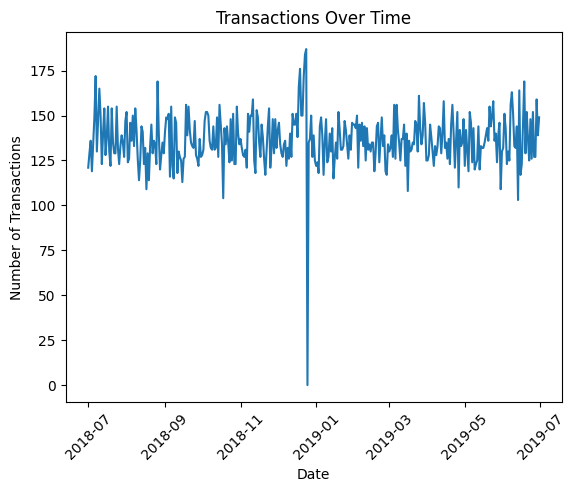

In [24]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(merged['DATE'], merged['num_transactions'])
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.title('Transactions Over Time')
plt.show()

In [25]:
missing_date = merged[merged['num_transactions'] == 0]
print(missing_date)

          DATE  num_transactions
177 2018-12-25               0.0


### We can see that there is an increase in purchases in December and a break in late December. Let's zoom in on this.

In [26]:
december_data = merged[
    (merged['DATE'] >= '2018-12-01') &
    (merged['DATE'] <= '2018-12-31')
]

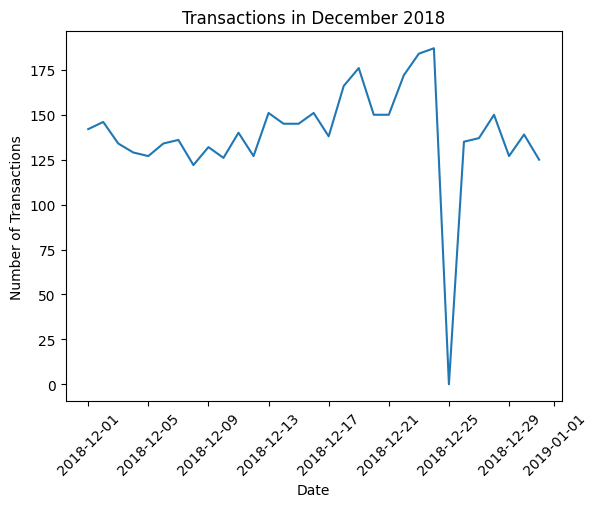

In [27]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(december_data['DATE'], december_data['num_transactions'])
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.title('Transactions in December 2018')
plt.show()

In [28]:
print(december_data.sort_values('num_transactions').head())

          DATE  num_transactions
177 2018-12-25               0.0
160 2018-12-08             122.0
183 2018-12-31             125.0
162 2018-12-10             126.0
164 2018-12-12             127.0


### We can see that the increase in sales occurs in the lead-up to Christmas and that there are zero sales on Christmas day itself. This is due to shops being closed on Christmas day.

### Now that we are satisfied that the data no longer has outliers, we can move on to creating other features such as brand of chips or pack size from PROD_NAME. We will start with pack size.

In [29]:
chips['PACK_SIZE'] = (
    chips['PROD_NAME']
    .str.extract(r'(\d+)\s*[gG]')
    .astype(float)
)

In [30]:
# Create a new column name Pack_size
chips['PROD_NAME'].str.contains(r'\d+\s*[gG]', na=False).sum()

np.int64(49770)

In [31]:
chips['PACK_SIZE'].value_counts().sort_index()

PACK_SIZE
110.0     9693
160.0     2970
170.0    15413
175.0    15493
200.0     3004
330.0     3197
Name: count, dtype: int64

In [32]:
print("Min pack size:", chips['PACK_SIZE'].min())
print("Max pack size:", chips['PACK_SIZE'].max())

Min pack size: 110.0
Max pack size: 330.0


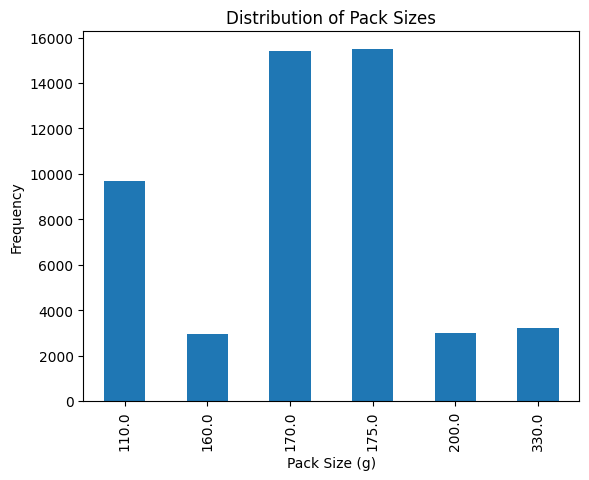

In [33]:
import matplotlib.pyplot as plt
plt.figure()
chips['PACK_SIZE'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Pack Size (g)')
plt.ylabel('Frequency')
plt.title('Distribution of Pack Sizes')
plt.show()

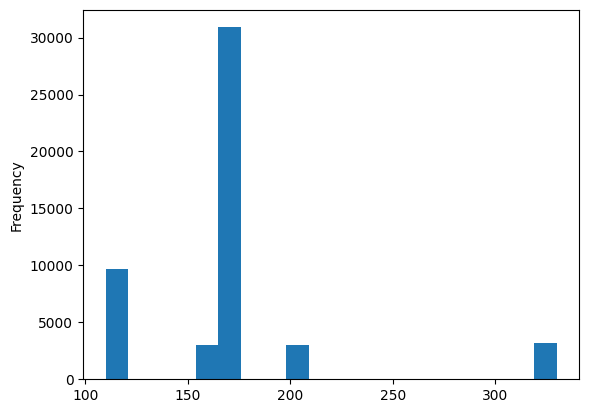

In [34]:
plt.figure()
chips['PACK_SIZE'].plot(kind='hist', bins=20)
plt.show()

Now to create brands, we can use the first word in PROD_NAME to work out the brand 
name...
```{r Create brand name}
Page 6
20200128_InsideSherpa_Task1_DraftSolutions - Template (1).Rmd
#### Brands
# Over to you! Create a column which contains the brand of the product, by 
extracting it from the product name.
#### Checking brands
# Over to you! Check the results look reasonable. 
```
Some of the brand names look like they are of the same brands - such as RED and 
RRD, which are both Red Rock Deli chips. Let's combine these together.
```{r Clean brand names}
#### Clean brand names
transactionData[BRAND == "RED", BRAND := "RRD"]
# Over to you! Add any additional brand adjustments you think may be required

In [35]:
chips['BRAND'] = (
    chips['PROD_NAME']
    .str.extract(r'^([A-Za-z]+)')
)

In [36]:
chips['BRAND'] = chips['BRAND'].str.upper()

In [37]:
brand_counts = (chips['BRAND'].value_counts().reset_index())
brand_counts.columns = ['BRAND', 'count']
print(brand_counts)

     BRAND  count
0    THINS  14075
1     COBS   9693
2  DORITOS   9498
3   SMITHS   9112
4       WW   5974
5   FRENCH   1418


In [38]:
chips.loc[chips['BRAND'] == 'RED', 'BRAND'] = 'RRD'

In [39]:
chips['BRAND'] = chips['BRAND'].replace({
    'RED': 'RRD',          # Red Rock Deli
    'SNBTS': 'SUNBITES',   # Sunbites typo/abbreviation
    'INFZNS': 'INFUZIONS'  # Infuzions typo
})

In [40]:
chips['BRAND'].unique()

<StringArray>
['SMITHS', 'THINS', 'DORITOS', 'COBS', 'FRENCH', 'WW']
Length: 6, dtype: str